# Long-memory & fractal analysis — `qufin.timeseries.fractal`

Is a price series *trending*, *mean-reverting*, or a pure *random walk*?
The **Hurst exponent** ``H`` answers this on a single ``[0, 1]`` scale:

* ``H ≈ 0.5`` — no memory; increments are independent (Brownian motion).
* ``H > 0.5`` — **persistent**: up-moves tend to follow up-moves (trending).
* ``H < 0.5`` — **anti-persistent**: moves tend to reverse (mean-reverting).

``H`` controls *self-similarity*: a series with exponent ``H`` rescales as
``x(ct) ≈ c^H x(t)``. The closely related **fractal dimension**
``D = 2 − H`` measures roughness: ``D → 1`` is a smooth curve, ``D → 2`` a
jagged, space-filling one.

**Sections**

0. Data — real returns (with a synthetic fallback)
1. Rescaled-range (R/S) analysis
2. Detrended fluctuation analysis (DFA)
3. Aggregated variance & method comparison
4. Validation on fractional Gaussian noise with known ``H``
5. Fractal dimension (Higuchi)
6. Rolling Hurst — detecting regime shifts


## Three ways to estimate H

All three estimators share one idea: a self-similar series obeys a
**power law** across scales, so the Hurst exponent is the *slope* of a
log-log regression.

| Estimator | Statistic vs scale ``n`` | Slope → H |
|---|---|---|
| **R/S** (Hurst 1951) | rescaled range ``R/S ∝ n^H`` | ``H = slope`` |
| **DFA** (Peng 1994) | detrended fluctuation ``F(n) ∝ n^α`` | ``α = H`` (noise) |
| **Aggregated variance** | ``Var(block mean) ∝ m^{2H−2}`` | ``H = 1 + slope/2`` |

R/S is the classic but is biased for short series and sensitive to trends.
DFA first *integrates* the series and removes a local polynomial trend in
each window, making it robust to non-stationarity — the modern default.
On an integrated (price) series DFA returns ``α = H + 1``, so always run
it on **returns**.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qufin.timeseries import (
    hurst, rs_analysis, dfa, aggregated_variance, fractal_dimension,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 0. Data

We try to pull a real equity series; if `yfinance` is offline the loader
falls back to a synthetic geometric Brownian motion so the notebook always
runs. Either way we work with **log returns** — the increment series the
Hurst estimators expect.


In [2]:
def load_log_returns(ticker='SPY', start='2015-01-01', end='2024-01-01'):
    try:
        import pandas as pd
        import yfinance as yf
        raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        close = raw['Close'].dropna().to_numpy(dtype='float64')
        if close.size > 500:
            return np.diff(np.log(close)), ticker
    except Exception as exc:  # offline / no yfinance
        print(f'yfinance unavailable ({exc!r}); using synthetic GBM')
    rng = np.random.default_rng(0)
    return rng.normal(0.0003, 0.01, size=2200), 'synthetic GBM'

rets, label = load_log_returns()
print(f'{label}: {rets.size} daily log returns, ann. vol ≈ {rets.std()*np.sqrt(252):.1%}')


SPY: 2263 daily log returns, ann. vol ≈ 18.2%


## 1. Rescaled-range (R/S) analysis

For each window size ``n`` the series is split into non-overlapping blocks;
each block contributes ``range(cumulative deviations) / std``. The slope of
``log(R/S)`` against ``log(n)`` is the Hurst exponent. The
``HurstResult.r_squared`` tells you how clean the power-law is.


Hurst(method='rs', H=0.5405, R²=0.9988, n=2263, scales=19)


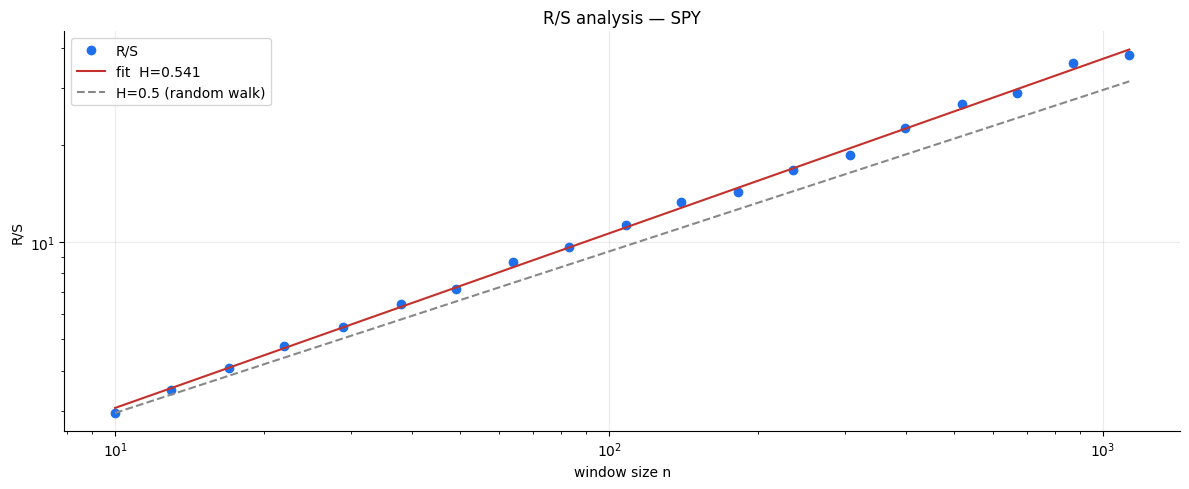

In [3]:
rs = rs_analysis(rets)
print(rs)

fig, ax = plt.subplots()
ax.loglog(rs.scales, rs.fluctuations, 'o', color='#1f6feb', label='R/S')
fit = np.exp(rs.intercept) * rs.scales.astype(float) ** rs.exponent
ax.loglog(rs.scales, fit, '-', color='#c4302b', label=f'fit  H={rs.exponent:.3f}')
# Reference H=0.5 line anchored at the first point.
ref = rs.fluctuations[0] * (rs.scales / rs.scales[0]) ** 0.5
ax.loglog(rs.scales, ref, '--', color='#888', label='H=0.5 (random walk)')
ax.set_xlabel('window size n'); ax.set_ylabel('R/S')
ax.set_title(f'R/S analysis — {label}'); ax.legend()
plt.tight_layout(); plt.show()


## 2. Detrended fluctuation analysis

DFA integrates the returns into a profile, removes a linear trend inside
each window, and measures the residual fluctuation ``F(n)``. It is the
most robust estimator when the data has slow trends or non-stationarity.


Hurst(method='dfa', H=0.4566, R²=0.9890, n=2263, scales=19)


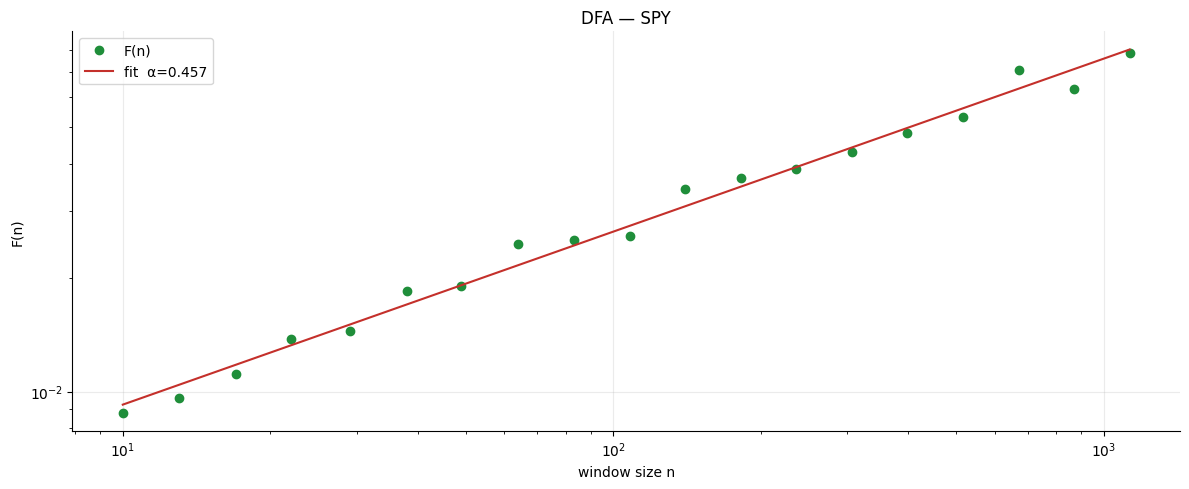

In [4]:
df = dfa(rets)
print(df)

fig, ax = plt.subplots()
ax.loglog(df.scales, df.fluctuations, 'o', color='#1f8e3a', label='F(n)')
fit = np.exp(df.intercept) * df.scales.astype(float) ** df.exponent
ax.loglog(df.scales, fit, '-', color='#c4302b', label=f'fit  α={df.exponent:.3f}')
ax.set_xlabel('window size n'); ax.set_ylabel('F(n)')
ax.set_title(f'DFA — {label}'); ax.legend()
plt.tight_layout(); plt.show()


## 3. Method comparison

The three estimators rarely agree to the third decimal — they weight
scales differently and have different small-sample biases. Treat the
*spread* across methods as an informal uncertainty band.


In [5]:
for name in ('rs', 'dfa', 'agg_var'):
    res = hurst(rets, method=name)
    print(f'{name:>8}:  H = {res.exponent:.3f}   (R² = {res.r_squared:.3f})')


      rs:  H = 0.541   (R² = 0.999)
     dfa:  H = 0.457   (R² = 0.989)
 agg_var:  H = 0.179   (R² = 0.947)


## 4. Validation on fractional Gaussian noise

To trust the estimators, run them on data with a *known* ``H``. We
synthesise exact fractional Gaussian noise (fGn) via the Cholesky factor
of its covariance matrix and check recovery across the persistence range.


In [6]:
from scipy.linalg import toeplitz

def fgn(n, H, seed=0):
    rng = np.random.default_rng(seed)
    k = np.arange(n, dtype=float)
    g = 0.5 * (np.abs(k+1)**(2*H) - 2*np.abs(k)**(2*H) + np.abs(k-1)**(2*H))
    return np.linalg.cholesky(toeplitz(g)) @ rng.standard_normal(n)

targets = [0.3, 0.5, 0.7, 0.9]
for H in targets:
    est = np.mean([rs_analysis(fgn(2000, H, s)).exponent for s in range(3)])
    print(f'true H = {H:.2f}  →  R/S estimate = {est:.3f}')


true H = 0.30  →  R/S estimate = 0.376


true H = 0.50  →  R/S estimate = 0.545


true H = 0.70  →  R/S estimate = 0.716


true H = 0.90  →  R/S estimate = 0.860


## 5. Fractal dimension (Higuchi)

Higuchi's method estimates the curve's fractal dimension ``D`` directly
from curve length vs sampling lag. For a price *path*, ``D`` near 1.5 is
the random-walk benchmark; smoother trends sit below, rougher series
above.


In [7]:
price_path = 100.0 * np.exp(np.cumsum(rets))
print(f'Higuchi D (price path)   : {fractal_dimension(price_path):.3f}')
print(f'D from Hurst (2 − H)     : {fractal_dimension(rets, method="hurst"):.3f}')
print(f'Smooth line D            : {fractal_dimension(np.linspace(0, 1, 500)):.3f}')
print(f'White-noise D            : {fractal_dimension(np.random.default_rng(1).standard_normal(2000)):.3f}')


Higuchi D (price path)   : 1.486
D from Hurst (2 − H)     : 1.459
Smooth line D            : 1.000
White-noise D            : 2.000


## 6. Rolling Hurst — regime detection

A *single* Hurst number hides time variation. Computing ``H`` on a sliding
window exposes regime shifts: stretches where the market trends
(``H > 0.5``) versus chops/mean-reverts (``H < 0.5``). This is a natural
gate for switching between momentum and mean-reversion strategies.


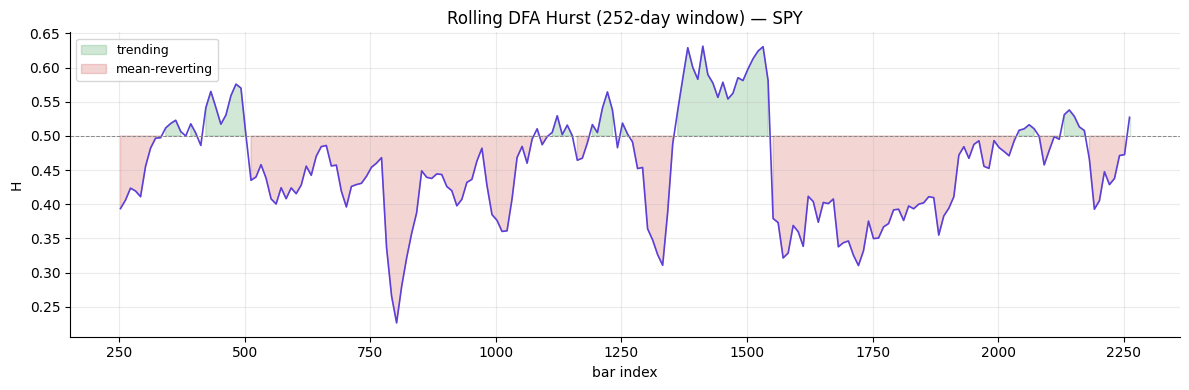

In [8]:
win = 252
step = 10
idx, hs = [], []
for end in range(win, rets.size, step):
    seg = rets[end-win:end]
    try:
        hs.append(hurst(seg, method='dfa').exponent)
        idx.append(end)
    except ValueError:
        pass
idx = np.array(idx); hs = np.array(hs)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(idx, hs, color='#5b3fd8', lw=1.2)
ax.axhline(0.5, color='#888', lw=0.7, ls='--')
ax.fill_between(idx, 0.5, hs, where=hs >= 0.5, color='#1f8e3a', alpha=0.2, label='trending')
ax.fill_between(idx, 0.5, hs, where=hs < 0.5, color='#c4302b', alpha=0.2, label='mean-reverting')
ax.set_title(f'Rolling DFA Hurst ({win}-day window) — {label}')
ax.set_xlabel('bar index'); ax.set_ylabel('H'); ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


## 7. Multifractal DFA

A single Hurst exponent assumes *mono*fractal scaling. Real markets are often
**multifractal**: small and large fluctuations scale differently. `mfdfa`
generalises DFA to a spectrum of exponents ``h(q)`` — flat ⇒ monofractal,
decreasing ⇒ multifractal. The width of the singularity spectrum ``f(α)``
quantifies the degree of multifractality. Shuffling the returns destroys the
temporal structure and collapses the spectrum, a standard sanity check.


multifractal width (data)     = 0.525
multifractal width (shuffled) = 0.321


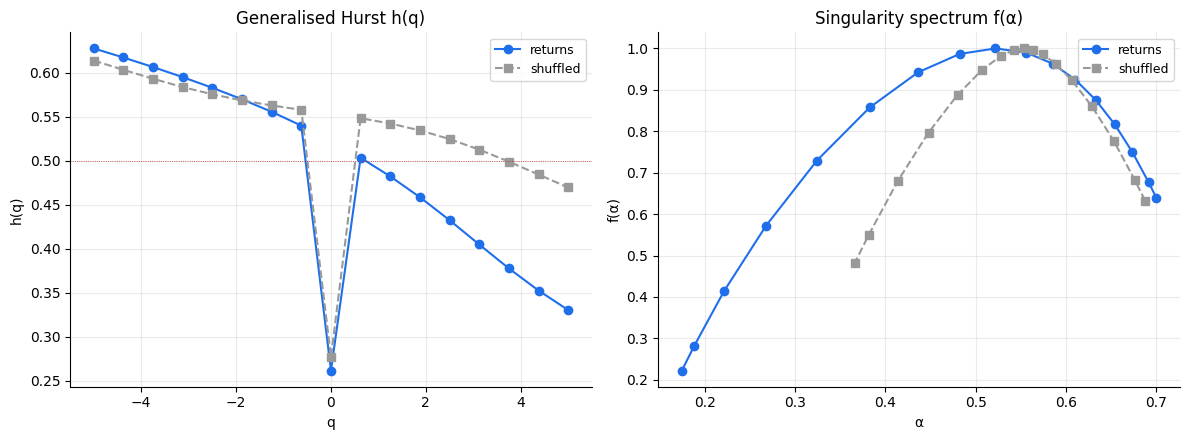

In [9]:
from qufin.timeseries import mfdfa

res_mf = mfdfa(rets)
shuffled = rets.copy(); np.random.default_rng(0).shuffle(shuffled)
res_sh = mfdfa(shuffled)
print(f'multifractal width (data)     = {res_mf.width:.3f}')
print(f'multifractal width (shuffled) = {res_sh.width:.3f}')

fig, (axh, axf) = plt.subplots(1, 2, figsize=(12, 4.5))
axh.plot(res_mf.q, res_mf.hq, 'o-', color='#1f6feb', label='returns')
axh.plot(res_sh.q, res_sh.hq, 's--', color='#999', label='shuffled')
axh.axhline(0.5, color='#c4302b', lw=0.6, ls=':')
axh.set_title('Generalised Hurst h(q)'); axh.set_xlabel('q'); axh.set_ylabel('h(q)'); axh.legend(fontsize=9)
axf.plot(res_mf.alpha, res_mf.f_alpha, 'o-', color='#1f6feb', label='returns')
axf.plot(res_sh.alpha, res_sh.f_alpha, 's--', color='#999', label='shuffled')
axf.set_title('Singularity spectrum f(α)'); axf.set_xlabel('α'); axf.set_ylabel('f(α)'); axf.legend(fontsize=9)
plt.tight_layout(); plt.show()


## What next?

* **Gate strategies on regime.** Feed the rolling Hurst into
  `qufin.strategies` — trade momentum when ``H > 0.5``, mean-reversion
  when ``H < 0.5``.
* **Pair with stationarity tests.** A low Hurst supports the
  mean-reversion case that `qufin.timeseries.adf` / `variance_ratio` test
  formally.
* **Cross-check cointegration spreads.** The residual spread of a
  cointegrated pair *should* be strongly anti-persistent (``H ≪ 0.5``) —
  a quick Hurst check is a cheap sanity filter before trading it.
